In [44]:
"""
prepare_smoother_data.py
========================
Reads the same DataParametrization.xlsx used for calibration and produces
a .mat file (peru_smoother_data.mat) with three demeaned quarterly series:

    q_tilde  :  HP-filtered log(p_im/p_ex) cycle   [fraction]
    e        :  demeaned log(PEN/USD)                [fraction]
    f_star   :  FXI / GDP                            [fraction of GDP, NOT percent]

All series are trimmed to the common sample and demeaned (model SS = 0).
"""

import pandas as pd
import numpy as np
from statsmodels.tsa.filters.hp_filter import hpfilter
from scipy.io import savemat
import json, os

# ── Paths (adjust if needed) ───────────────────────────────────────────────
DATA_PATH   = "../data/DataParametrization.xlsx"
OUTPUT_PATH = "model/peru_smoother_data.mat"

In [45]:
# ── 1. Load sheets ─────────────────────────────────────────────────────────
data_q = pd.read_excel(DATA_PATH, sheet_name="Quarterly", index_col="date")
data_m = pd.read_excel(DATA_PATH, sheet_name="Monthly",   index_col="date")
data_d = pd.read_excel(DATA_PATH, sheet_name="Daily",     index_col="date")
 
for col in ['tot', 'px', 'pm', 'X', 'M', 'Y', 'Y_e']:
    if col in data_q.columns:
        data_q[col] = pd.to_numeric(data_q[col], errors='coerce')
 
# ── Diagnostics ────────────────────────────────────────────────────────────
print("=== INDEX DIAGNOSTICS ===")
print(f"Quarterly index[:5]: {list(data_q.index[:5])}")
print(f"Quarterly shape:     {data_q.shape}")
print(f"Monthly index[:3]:   {list(data_m.index[:3])}")
print(f"Daily index[:3]:     {list(data_d.index[:3])}")
print()
 

=== INDEX DIAGNOSTICS ===
Quarterly index[:5]: ['T100', 'T200', 'T300', 'T400', 'T101']
Quarterly shape:     (106, 8)
Monthly index[:3]:   [Timestamp('2000-01-01 00:00:00'), Timestamp('2000-02-01 00:00:00'), Timestamp('2000-03-01 00:00:00')]
Daily index[:3]:     [Timestamp('2000-01-03 00:00:00'), Timestamp('2000-01-04 00:00:00'), Timestamp('2000-01-05 00:00:00')]



In [46]:
# ── 2. Build calendar dates for quarterly sheet ────────────────────────────
# T100 = 2000Q1.  T100 + k = quarter k from 2000Q1.
q_start_date = pd.Timestamp('2000-03-31')  # end of 2000Q1
n_q = len(data_q)
q_cal_dates = pd.date_range(start=q_start_date, periods=n_q, freq='QE')
# Assign calendar dates to quarterly dataframe
data_q['cal_date'] = q_cal_dates.values
print(f"Quarterly calendar: {q_cal_dates[0].date()} to {q_cal_dates[-1].date()} ({n_q} obs)")

Quarterly calendar: 2000-03-31 to 2026-06-30 (106 obs)


In [47]:
# ── 3. q_tilde: pass-through-adjusted HP-filtered ToT cycle ────────────────
#    The model's q_tilde is the natural RER, not raw ToT.
#    q_tilde_t = beta_passthrough * tot_cycle_t
#    where beta_passthrough comes from OLS: Δlog(S) on Δlog(p_im/p_ex).
 
import statsmodels.api as sm
 
tot_mask = data_q['tot'].notna()
tot_log = np.log(1.0 / data_q.loc[tot_mask, 'tot'].astype(float))
q_cycle, _ = hpfilter(tot_log, lamb=1600)
 
# Compute pass-through beta (same regression as calibration code)
exrate_for_beta = pd.to_numeric(data_m['exrate'], errors='coerce').dropna()
ln_e_beta = np.log(exrate_for_beta.resample('QE').mean()).dropna()
de = ln_e_beta.diff().dropna().values
dtot = np.diff(tot_log.values)
# Trim to same length
n_beta = min(len(de), len(dtot))
de   = de[:n_beta]
dtot = dtot[:n_beta]
X_beta = sm.add_constant(dtot)
beta_passthrough = sm.OLS(de, X_beta).fit().params[1]
print(f"Pass-through beta: {beta_passthrough:.4f}")
 
# Scale the cycle
q_tilde_scaled = beta_passthrough * q_cycle.values 
 
s_qtilde = pd.Series(q_tilde_scaled,
                      index=data_q.loc[tot_mask, 'cal_date'].values,
                      name='q_tilde')
print(f"q_tilde: {len(s_qtilde)} obs, {s_qtilde.index[0]} to {s_qtilde.index[-1]}")
print(f"  (scaled by beta={beta_passthrough:.4f})")
 

Pass-through beta: 0.1237
q_tilde: 102 obs, 2000-03-31 00:00:00 to 2025-06-30 00:00:00
  (scaled by beta=0.1237)


/opt/homebrew/Caskroom/miniforge/base/envs/lab/lib/python3.14/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)


<Axes: title={'center': 'log(1/ToT)'}, xlabel='Date', ylabel='log(1/ToT)'>

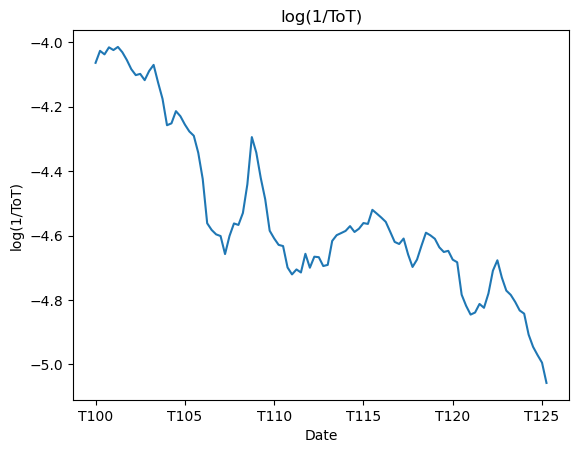

In [ ]:
tot_log.plot.line(title="log(1/ToT)", ylabel="log(1/ToT)", xlabel="Date")

<Axes: title={'center': 'q_tilde (pass-through-adjusted HP-filtered ToT cycle)'}, xlabel='Date', ylabel='q_tilde [fraction]'>

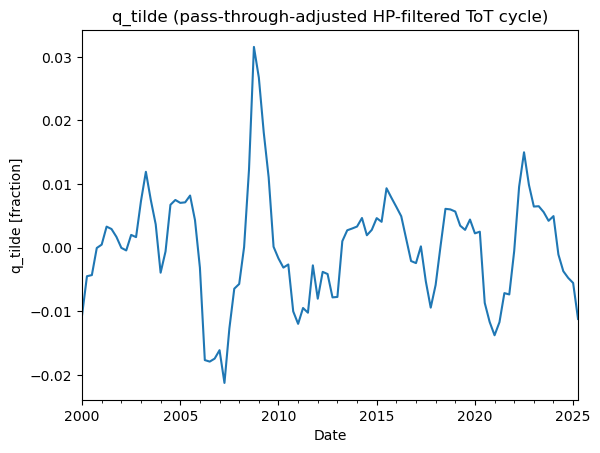

In [48]:
s_qtilde.plot.line(title="q_tilde (pass-through-adjusted HP-filtered ToT cycle)", ylabel="q_tilde [fraction]", xlabel="Date")

In [49]:
# ── 4. e: demeaned log(PEN/USD) ────────────────────────────────────────────
exrate_m = pd.to_numeric(data_m['exrate'], errors='coerce').dropna()
exrate_q = exrate_m.resample('QE').mean().dropna()
ln_e = np.log(exrate_q)
s_e = ln_e - ln_e.mean()
s_e.name = 'e'
de = ln_e.diff().dropna()
s_de = de - de.mean()  # demean
s_de.name = 'de'
print(f"e:       {len(s_e)} obs, {s_e.index[0].date()} to {s_e.index[-1].date()}")
print(f"de:      {len(s_de)} obs, {s_de.index[0].date()} to {s_de.index[-1].date()}")
print(f"  (Δlog(S), Std={s_de.std():.4f}, Var={s_de.var():.6f})")

# ── 4b. HP-filtered de: first difference of HP cycle of log(PEN/USD) ──────
#    Removes low-frequency trend from e, so n* only explains cyclical movements.
#    Comment/uncomment to switch between raw de and filtered de.
e_cycle, e_trend = hpfilter(np.log(exrate_m), lamb=14400)
ln_e_cycle = e_cycle.resample('QE').mean().dropna()
de_filtered = ln_e_cycle.diff().dropna()
s_de = de_filtered - de_filtered.mean()  # overwrite s_de with filtered version
s_de.name = 'de'
print(f"de (HP): {len(s_de)} obs, {s_de.index[0].date()} to {s_de.index[-1].date()}")
print(f"  (ΔHP-cycle, Std={s_de.std():.4f}, Var={s_de.var():.6f})")

# ── 4c. psi: UIP residual = Δe_{t+1} - (i_t - i*_t), quarterly ───────────
#    This is the ex-post UIP deviation, the empirical counterpart of
#    the friction ω̄σ²(n* + f* - b*) in the I-M model.
exrate_m = pd.to_numeric(data_m['exrate'], errors='coerce').dropna()
exrate_expect_m = pd.to_numeric(data_m['e(+1)'], errors='coerce').dropna()
irate_m  = pd.to_numeric(data_m['irate'],  errors='coerce').dropna()
ffrate_m = pd.to_numeric(data_m['fedfunds'], errors='coerce').dropna()

ln_e_m = np.log(exrate_m)
de_m = np.log(exrate_expect_m) - np.log(exrate_m)  # Δe_{t+1} = ln(S_{t+1}) - ln(S_t)
#de_m = ln_e_m.diff().shift(-1)  # Δe_{t+1} = ln(S_{t+1}) - ln(S_t)
i_diff_m = (irate_m - ffrate_m) / 100  # monthly, convert from annualized %

psi_m = de_m - i_diff_m/12 # UIP residual

# Aggregate to quarterly
psi_q = psi_m.resample('QE').mean().dropna()
s_psi = psi_q - psi_q.mean()  # demean
s_psi.name = 'psi'
print(f"psi:     {len(s_psi)} obs, {s_psi.index[0].date()} to {s_psi.index[-1].date()}")
print(f"  (UIP residual, Std={s_psi.std():.6f})")

e:       105 obs, 2000-03-31 to 2026-03-31
de:      104 obs, 2000-06-30 to 2026-03-31
  (Δlog(S), Std=0.0229, Var=0.000525)
de (HP): 104 obs, 2000-06-30 to 2026-03-31
  (ΔHP-cycle, Std=0.0203, Var=0.000412)
psi:     78 obs, 2006-12-31 to 2026-03-31
  (UIP residual, Std=0.021098)


/opt/homebrew/Caskroom/miniforge/base/envs/lab/lib/python3.14/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)


In [50]:
de_filtered.var()

np.float64(0.00041242711221623656)

In [51]:
ln_e[80:]

date
2020-03-31    1.224922
2020-06-30    1.232693
2020-09-30    1.265787
2020-12-31    1.281683
2021-03-31    1.297447
2021-06-30    1.333762
2021-09-30    1.397709
2021-12-31    1.392197
2022-03-31    1.336571
2022-06-30    1.321464
2022-09-30    1.358919
2022-12-31    1.359685
2023-03-31    1.339764
2023-06-30    1.308741
2023-09-30    1.302008
2023-12-31    1.329768
2024-03-31    1.324212
2024-06-30    1.320285
2024-09-30    1.323971
2024-12-31    1.323446
2025-03-31    1.307996
2025-06-30    1.295835
2025-09-30    1.262349
2025-12-31    1.219129
2026-03-31    1.210784
Freq: QE-DEC, Name: exrate, dtype: float64

<Axes: title={'center': 'Log(PEN/USD) and HP Trend'}, xlabel='date'>

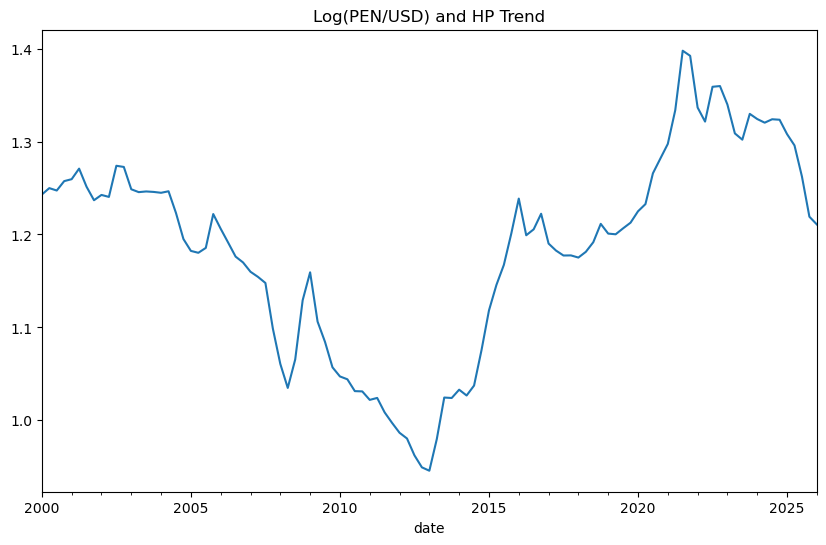

In [52]:
ln_e.plot.line(title="Log(PEN/USD) and HP Trend", figsize=(10, 6))

<Axes: title={'center': 'Log(PEN/USD) and HP Trend'}, xlabel='date'>

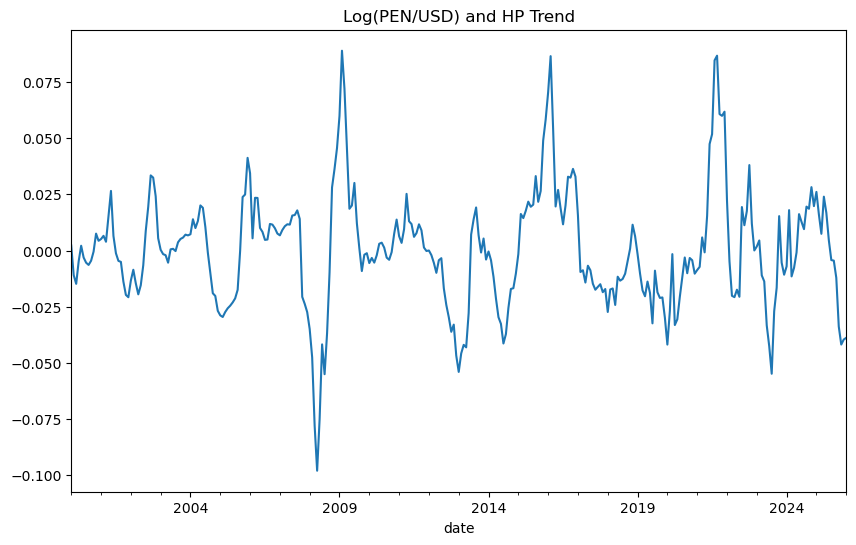

In [53]:
e_cycle.plot.line(title="Log(PEN/USD) and HP Trend", figsize=(10, 6))

<Axes: title={'center': 'Demeaned Δlog(PEN/USD)'}, xlabel='date'>

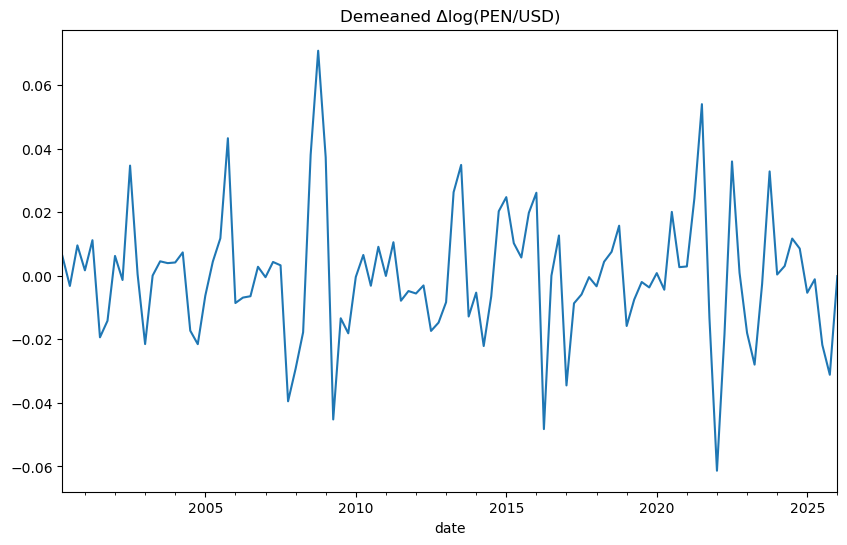

In [54]:
s_de.plot.line(title="Demeaned Δlog(PEN/USD)", figsize=(10, 6))

In [55]:
# ── 5. f_star: FXI / GDP (fraction, not percent) ──────────────────────────
fx_spot = pd.to_numeric(data_d['fx_spot'], errors='coerce')
fx_cdr  = pd.to_numeric(data_d['fx_cdr'],  errors='coerce')
fx_swap = pd.to_numeric(data_d['fx_swap'],  errors='coerce')
fxi_daily = fx_spot - fx_cdr - fx_swap
fxi_q = fxi_daily.resample('QE').sum().dropna()
 
# Drop last quarter if potentially incomplete
fxi_q = fxi_q.iloc[:-1]
 
# Y_e from quarterly sheet, with calendar dates
Ye_mask = data_q['Y_e'].notna()
s_Ye = pd.Series(data_q.loc[Ye_mask, 'Y_e'].values,
                  index=data_q.loc[Ye_mask, 'cal_date'].values,
                  name='Y_e')
 
# Build tradable output denominator: (X+M) converted to USD via (Y/Y_e) ratio
XM_mask = data_q['X'].notna() & data_q['M'].notna() & data_q['Y'].notna() & data_q['Y_e'].notna()
X_pen = pd.to_numeric(data_q.loc[XM_mask, 'X'], errors='coerce').values
M_pen = pd.to_numeric(data_q.loc[XM_mask, 'M'], errors='coerce').values
Y_pen = pd.to_numeric(data_q.loc[XM_mask, 'Y'], errors='coerce').values
Y_usd = pd.to_numeric(data_q.loc[XM_mask, 'Y_e'], errors='coerce').values
 
# (X+M)_USD = (X+M)_PEN * (Y_USD / Y_PEN)
trade_usd = (X_pen + M_pen) * (Y_usd / Y_pen)
 
s_trade = pd.Series(trade_usd,
                     index=data_q.loc[XM_mask, 'cal_date'].values,
                     name='trade_usd')


# Align by quarter-end date
common_idx = fxi_q.index.intersection(s_Ye.index)
f_raw = fxi_q.loc[common_idx].values / s_Ye.loc[common_idx].values
s_fstar = pd.Series(f_raw, index=common_idx, name='f_star')
print(f"f_star:  {len(s_fstar)} obs, {s_fstar.index[0].date()} to {s_fstar.index[-1].date()}")

f_star:  104 obs, 2000-03-31 to 2025-12-31


In [56]:
# ── 6. Trim to common sample ──────────────────────────────────────────────
# Convert all indexes to same type for comparison
s_qtilde.index = pd.DatetimeIndex(s_qtilde.index)
s_de.index     = pd.DatetimeIndex(s_de.index)
s_psi.index    = pd.DatetimeIndex(s_psi.index)
s_fstar.index  = pd.DatetimeIndex(s_fstar.index)
 
t0 = max(s_qtilde.index.min(), s_de.index.min(), s_fstar.index.min())
t1 = min(s_qtilde.index.max(), s_de.index.max(), s_fstar.index.max())
print(f"\nCommon window: {t0.date()} to {t1.date()}")
 
s_qtilde = s_qtilde.loc[t0:t1]
s_de      = s_de.loc[t0:t1]
s_fstar  = s_fstar.loc[t0:t1]
s_psi    = s_psi.loc[t0:t1]
 
# Check alignment
lens = [len(s_qtilde), len(s_de), len(s_fstar)]
print(f"Lengths: q_tilde={lens[0]}, de={lens[1]}, f_star={lens[2]}")
 
if not (lens[0] == lens[1] == lens[2]):
    print("WARNING: lengths differ after date trim.")
    print("  Falling back to positional alignment with min length.")
    T = min(lens)
    s_qtilde = s_qtilde.iloc[:T]
    s_de      = s_de.iloc[:T]
    s_fstar  = s_fstar.iloc[:T]
    s_psi    = s_psi.iloc[:T]
else:
    T = lens[0]
 
print(f"Final sample: {T} quarters\n")


Common window: 2000-06-30 to 2025-06-30
Lengths: q_tilde=101, de=101, f_star=101
Final sample: 101 quarters



In [57]:
# ── 7. Demean ──────────────────────────────────────────────────────────────
s_qtilde = s_qtilde - s_qtilde.mean()  # HP cycle, ~0 already
s_de      = s_de - s_de.mean()            # re-demean on subsample
fstar_mean = s_fstar.mean()
print(f"f_star mean before demeaning: {fstar_mean:.6f}")
s_fstar = s_fstar - fstar_mean
 
print(f"\n{'Variable':<12} {'Mean':>14} {'Std':>12} {'Min':>12} {'Max':>12}")
print("-" * 66)
for nm, s in [('q_tilde', s_qtilde), ('de', s_de), ('f_star', s_fstar)]:
    print(f"{nm:<12} {s.mean():>14.10f} {s.std():>12.6f} {s.min():>12.6f} {s.max():>12.6f}")
 

f_star mean before demeaning: -0.004227

Variable               Mean          Std          Min          Max
------------------------------------------------------------------
q_tilde        0.0000000000     0.008696    -0.021344     0.031446
de             0.0000000000     0.020251    -0.061873     0.070249
f_star         0.0000000000     0.067964    -0.174866     0.265186


In [58]:
# ── 8. Save .mat ──────────────────────────────────────────────────────────
mat_dict = {
    'q_tilde': s_qtilde.values.reshape(-1, 1),
    'de':      s_de.values.reshape(-1, 1),
    #'psi':     s_psi.values.reshape(-1, 1),
    'f_star':  s_fstar.values.reshape(-1, 1),
}
savemat(OUTPUT_PATH, mat_dict)
print(f"\nSaved {OUTPUT_PATH} ({T} obs)")


Saved model/peru_smoother_data.mat (101 obs)


In [59]:
# ── 9. Save CSV ────────────────────────────────────────────────────────────
df_out = pd.DataFrame({
    'date':    s_qtilde.index,
    'q_tilde': s_qtilde.values,
    'de':      s_de.values,
    #'psi':     s_psi.values,
    'f_star':  s_fstar.values,
})
df_out.to_csv('peru_smoother_data.csv', index=False)
print(f"Saved peru_smoother_data.csv")

Saved peru_smoother_data.csv


In [60]:
# ── 10. 2021 episode ──────────────────────────────────────────────────────
print("\n=== 2021 EPISODE ===")
for nm, s in [('q_tilde', s_qtilde), ('e', s_de), ('psi', s_psi), ('f_star', s_fstar)]:
    mask = (s.index >= '2021-01-01') & (s.index <= '2021-12-31')
    v = s.loc[mask]
    if len(v) > 0:
        print(f"\n{nm}:")
        for d, val in v.items():
            qnum = (d.month - 1) // 3 + 1
            print(f"  {d.year}Q{qnum}: {val:+.6f}")


=== 2021 EPISODE ===

q_tilde:
  2021Q1: -0.013856
  2021Q2: -0.011800
  2021Q3: -0.007234
  2021Q4: -0.007444

e:
  2021Q1: +0.002386
  2021Q2: +0.023810
  2021Q3: +0.053439
  2021Q4: -0.013780

psi:
  2021Q1: -0.044868
  2021Q2: -0.042827
  2021Q3: +0.006008
  2021Q4: +0.019409

f_star:
  2021Q1: -0.174866
  2021Q2: -0.091301
  2021Q3: -0.126200
  2021Q4: -0.087398


In [61]:
# ── 11. Info for MATLAB script ─────────────────────────────────────────────
sd = s_qtilde.index[0]
sq = (sd.month - 1) // 3 + 1
print(f"\n=== FOR extract_smoothed_shocks.m ===")
print(f"start_year = {sd.year};")
print(f"start_qtr  = {sq};")


=== FOR extract_smoothed_shocks.m ===
start_year = 2000;
start_qtr  = 2;
